In [11]:
import torch
from torchvision import models, transforms

from pathlib import Path
from PIL import Image
import ml_modules

In [21]:
device = 'cuda' if torch.cuda.is_available() else 'cpu' 

In [49]:
classes = ['0', '1', '2', '3', '4']

In [8]:
model = models.vit_b_32()
model.load_state_dict(torch.load('./models/80-percent.pt'), strict=False)

_IncompatibleKeys(missing_keys=['heads.head.weight', 'heads.head.bias'], unexpected_keys=['heads.0.weight', 'heads.0.bias'])

In [78]:
test_image = Path("../dataset/aptos2019/train/1")
test_images_path = list(test_image.glob('*.png'))
# test_image = Image.open(test_image / "0a4e1a29ffff.png")

In [79]:

normalize = transforms.Normalize(

    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

test_transform = transforms.Compose([

    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])

In [80]:
transformed_image = test_transform(test_image)
transformed_image.shape

TypeError: Unexpected type <class 'pathlib.WindowsPath'>

In [81]:
test_images_path

[WindowsPath('../dataset/aptos2019/train/1/0024cdab0c1e.png'),
 WindowsPath('../dataset/aptos2019/train/1/00cb6555d108.png'),
 WindowsPath('../dataset/aptos2019/train/1/0124dffecf29.png'),
 WindowsPath('../dataset/aptos2019/train/1/01b3aed3ed4c.png'),
 WindowsPath('../dataset/aptos2019/train/1/0369f3efe69b.png'),
 WindowsPath('../dataset/aptos2019/train/1/03e25101e8e8.png'),
 WindowsPath('../dataset/aptos2019/train/1/04ac765f91a1.png'),
 WindowsPath('../dataset/aptos2019/train/1/059bc89df7f4.png'),
 WindowsPath('../dataset/aptos2019/train/1/05a5183c92d0.png'),
 WindowsPath('../dataset/aptos2019/train/1/0684311afdfc.png'),
 WindowsPath('../dataset/aptos2019/train/1/06b71823f9cd.png'),
 WindowsPath('../dataset/aptos2019/train/1/07929d32b5b3.png'),
 WindowsPath('../dataset/aptos2019/train/1/07a1c7073982.png'),
 WindowsPath('../dataset/aptos2019/train/1/086d41d17da8.png'),
 WindowsPath('../dataset/aptos2019/train/1/09935d72892b.png'),
 WindowsPath('../dataset/aptos2019/train/1/0a3202889f4d

In [83]:
ml_modules.make_predictions(model=model,
                            image=test_transform(test_image),
                            classes=classes,
                            device=device)

TypeError: Unexpected type <class 'pathlib.WindowsPath'>

In [85]:
# import random
# image_path_list = random.sample(test_images_path, k=4)

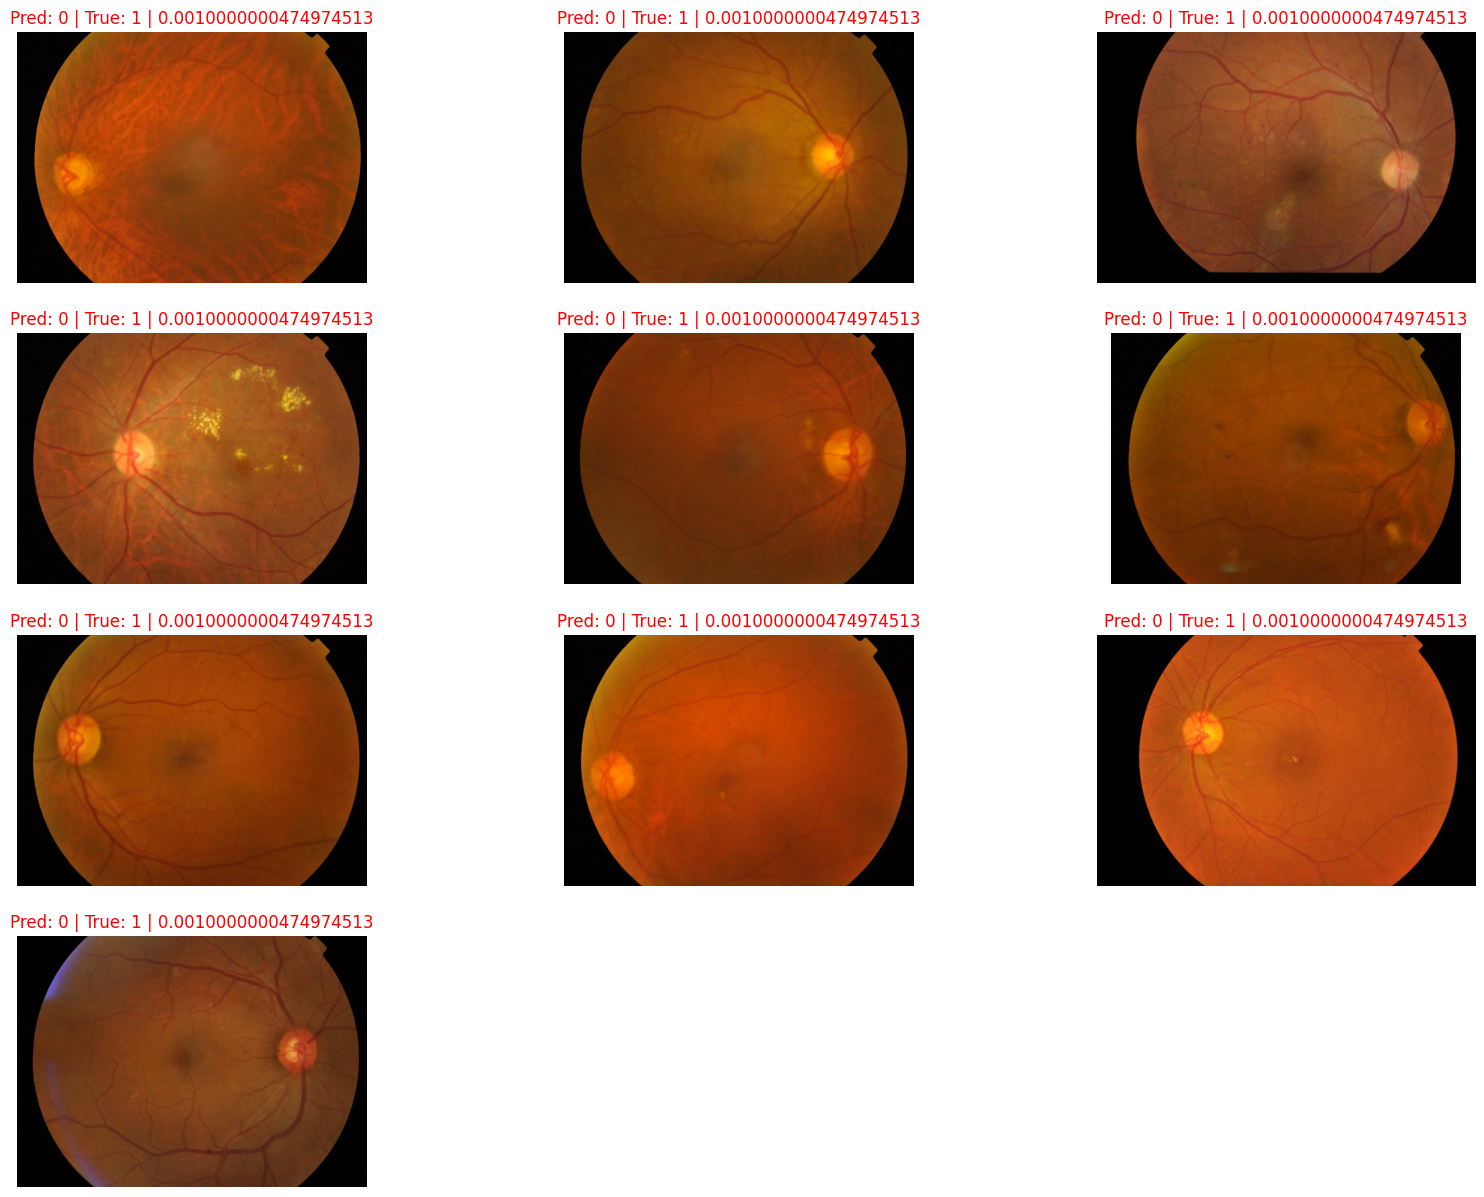

In [86]:
ml_modules.plot_predictions(model=model,
                            image_path_list=test_images_path,
                            transform=test_transform,
                            classes=classes,
                            device=device,
                            k=10)